## Install Libraries


In [ ]:
# !pip install transformers datasets soundfile speechbrain==0.5.16 accelerate
!pip install transformers datasets soundfile accelerate

In [ ]:
!pip install speechbrain --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 48.8 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
from datasets import load_dataset, Audio
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, Seq2SeqTrainingArguments, Seq2SeqTrainer, SpeechT5HifiGan
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import torch
from speechbrain.pretrained import EncoderClassifier
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from functools import partial
from huggingface_hub import notebook_login, login

In [ ]:
login(token=userdata.get("HF_TOKEN"))

## Load Dataset

[Voxpopuli Dataset](https://huggingface.co/datasets/facebook/voxpopuli) is being used for training the model.

In this case, the Dutch (nl) language subset of the VoxPopuli dataset is being used. VoxPopuli is a large-scale multilingual speech corpus consisting of data sourced from 2009-2020 European Parliament event recordings. It contains labelled audio-transcription data for 15 European languages.

This is an automated speech recognition (ASR) dataset, so, as mentioned before, it is not the most suitable option for training TTS models. However, it will be good enough for this exercise.

Let’s load the data:

In [ ]:
# Load the dataset
dataset = load_dataset("facebook/voxpopuli", "nl", split="train",token=userdata.get("HF_TOKEN"))

# Take a random subset of 1/4th of the dataset
subset_size = len(dataset) // 4
subset = dataset.shuffle(seed=42).select(range(subset_size))

# Verify the subset size
print(f"Original dataset size: {len(dataset)}")
print(f"Subset dataset size: {len(subset)}")

README.md: 0.00B [00:00, ?B/s]

nl/train-00000-of-00003.parquet:   0%|          | 0.00/2.90G [00:00<?, ?B/s]

nl/train-00001-of-00003.parquet:   0%|          | 0.00/2.97G [00:00<?, ?B/s]

nl/train-00002-of-00003.parquet:   0%|          | 0.00/2.96G [00:00<?, ?B/s]

nl/validation-00000-of-00001.parquet:   0%|          | 0.00/505M [00:00<?, ?B/s]

nl/test-00000-of-00001.parquet:   0%|          | 0.00/502M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20968 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1230 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1137 [00:00<?, ? examples/s]

Original dataset size: 20968
Subset dataset size: 5242


In [ ]:
dataset=subset

In [ ]:
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

In [ ]:
dataset

Dataset({
    features: ['audio_id', 'language', 'audio', 'raw_text', 'normalized_text', 'gender', 'speaker_id', 'is_gold_transcript', 'accent'],
    num_rows: 5242
})

In [ ]:
dataset[0]

{'audio_id': '20150909-0900-PLENARY-13-nl_20150909-19:06:12_8',
 'language': 9,
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7e5b912ec890>,
 'raw_text': 'Dat wil ik u vooral meegeven, en vooral de vraag hoe staat het met de implementatie en de controle, een dubbele controle, gezien het verleden.',
 'normalized_text': 'dat wil ik u vooral meegeven en vooral de vraag hoe staat het met de implementatie en de controle een dubbele controle gezien het verleden.',
 'gender': 'male',
 'speaker_id': '4507',
 'is_gold_transcript': True,
 'accent': 'None'}

## Data Preprocessing

In [ ]:
checkpoint = "microsoft/speecht5_tts"
processor = SpeechT5Processor.from_pretrained(checkpoint)

preprocessor_config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/232 [00:00<?, ?B/s]

spm_char.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

In [ ]:
tokenizer = processor.tokenizer

In [ ]:
def extract_all_chars(batch):
    all_text = " ".join(batch["normalized_text"])
    vocab = list(set(all_text))
    return {"vocab": [vocab], "all_text": [all_text]}


vocabs = dataset.map(
    extract_all_chars,
    batched=True,
    batch_size=-1,
    keep_in_memory=True,
    remove_columns=dataset.column_names,
)

dataset_vocab = set(vocabs["vocab"][0])
tokenizer_vocab = {k for k, _ in tokenizer.get_vocab().items()}

Map:   0%|          | 0/5242 [00:00<?, ? examples/s]

Now you have two sets of characters: one with the vocabulary from the dataset and one with the vocabulary from the tokenizer. To identify any unsupported characters in the dataset, we take the difference between these two sets. The resulting set will contain the characters that are in the dataset but not in the tokenizer.

In [ ]:
dataset_vocab - tokenizer_vocab

{' ', 'à', 'è', 'ë', 'í', 'ï', 'ö', 'ü'}

In [ ]:
replacements = [
    ("à", "a"),
    ("ç", "c"),
    ("è", "e"),
    ("ë", "e"),
    ("í", "i"),
    ("ï", "i"),
    ("ö", "o"),
    ("ü", "u"),
]


def cleanup_text(inputs):
    for src, dst in replacements:
        inputs["normalized_text"] = inputs["normalized_text"].replace(src, dst)
    return inputs


dataset = dataset.map(cleanup_text)

Map:   0%|          | 0/5242 [00:00<?, ? examples/s]

## Speakers

The VoxPopuli dataset includes speech from multiple speakers, but how many speakers are represented in the dataset? To determine this, we can count the number of unique speakers and the number of examples each speaker contributes to the dataset. With a total of 20,968 examples in the dataset, this information will give us a better understanding of the distribution of speakers and examples in the data.

In [ ]:
speaker_counts = defaultdict(int)

for speaker_id in dataset["speaker_id"]:
    speaker_counts[speaker_id] += 1

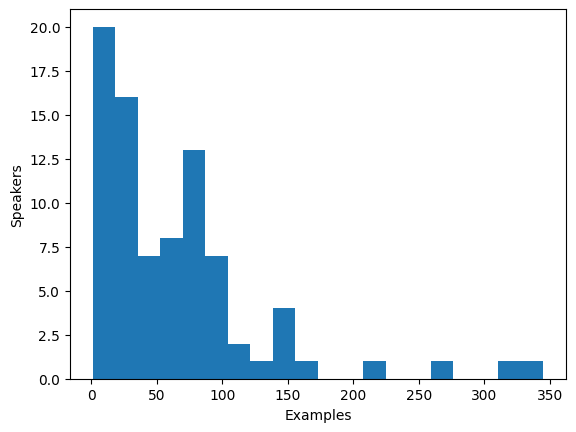

In [ ]:
plt.figure()
plt.hist(speaker_counts.values(), bins=20)
plt.ylabel("Speakers")
plt.xlabel("Examples")
plt.show()

The histogram reveals that approximately one-third of the speakers in the dataset have fewer than 100 examples, while around ten speakers have more than 500 examples. To improve training efficiency and balance the dataset, we can limit the data to speakers with between 100 and 400 examples.

In [ ]:
def select_speaker(speaker_id):
    return 100 <= speaker_counts[speaker_id] <= 400


dataset = dataset.filter(select_speaker, input_columns=["speaker_id"])

Filter:   0%|          | 0/5242 [00:00<?, ? examples/s]

In [ ]:
len(set(dataset["speaker_id"]))

14

In [ ]:
len(dataset)

2442

In [ ]:
spk_model_name = "speechbrain/spkrec-xvect-voxceleb"
device = "cuda" if torch.cuda.is_available() else "cpu"

speaker_model = EncoderClassifier.from_hparams(
    source=spk_model_name,
    savedir=os.path.join("/tmp", spk_model_name),
    run_opts={"device": device}
)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/tmp/speechbrain/spkrec-xvect-voxceleb/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/tmp/speechbrain/spkrec-xvect-voxceleb/embedding_model.ckpt'
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/tmp/speechbrain/spkrec-xvect-voxceleb/mean_var_norm_emb.ckpt'
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Using symlink found at '/tmp/speechbrain/spkrec-xvect-voxceleb/classifier.ckpt'
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Using symlink found at '/tmp/speechbrain/spkrec-xvect-voxceleb/label_encoder.ckpt'
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


In [ ]:
def create_speaker_embedding(waveform):
    with torch.no_grad():
        speaker_embeddings = speaker_model.encode_batch(torch.tensor(waveform))
        speaker_embeddings = torch.nn.functional.normalize(speaker_embeddings, dim=2)
        speaker_embeddings = speaker_embeddings.squeeze().cpu().numpy()
    return speaker_embeddings

##  Data Preprocessing

Finally, let’s process the data into the format the model expects. Create a prepare_dataset function that takes in a single example and uses the SpeechT5Processor object to tokenize the input text and load the target audio into a log-mel spectrogram. It should also add the speaker embeddings as an additional input.

In [ ]:
def prepare_dataset(example):
    audio = example["audio"]

    example = processor(
        text=example["normalized_text"],
        audio_target=audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_attention_mask=False,
    )

    # strip off the batch dimension
    example["labels"] = example["labels"][0]

    # use SpeechBrain to obtain x-vector
    example["speaker_embeddings"] = create_speaker_embedding(audio["array"])

    return example

In [ ]:
processed_example = prepare_dataset(dataset[0])
list(processed_example.keys())

['input_ids', 'labels', 'speaker_embeddings']

In [ ]:
processed_example["speaker_embeddings"].shape

(512,)

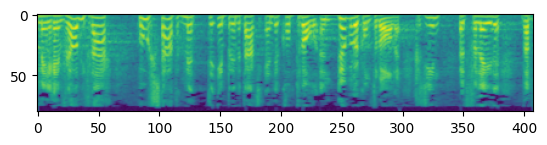

In [ ]:
plt.figure()
plt.imshow(processed_example["labels"].T)
plt.show()

In [ ]:
dataset = dataset.map(prepare_dataset, remove_columns=dataset.column_names)

Map:   0%|          | 0/2442 [00:00<?, ? examples/s]

In [ ]:
def is_not_too_long(input_ids):
    input_length = len(input_ids)
    return input_length < 200


dataset = dataset.filter(is_not_too_long, input_columns=["input_ids"])
len(dataset)

Filter:   0%|          | 0/2442 [00:00<?, ? examples/s]

2057

In [ ]:
dataset = dataset.train_test_split(test_size=0.1)

## Data collator

In order to combine multiple examples into a batch, we need to define a custom data collator. This collator will pad shorter sequences with padding tokens, ensuring that all examples have the same length. For the spectrogram labels, the padded portions are replaced with the special value -100. This special value instructs the model to ignore that part of the spectrogram when calculating the spectrogram loss.

In [ ]:
@dataclass
class TTSDataCollatorWithPadding:
    processor: Any

    def __call__(
        self, features: List[Dict[str, Union[List[int], torch.Tensor]]]
    ) -> Dict[str, torch.Tensor]:
        input_ids = [{"input_ids": feature["input_ids"]} for feature in features]
        label_features = [{"input_values": feature["labels"]} for feature in features]
        speaker_features = [feature["speaker_embeddings"] for feature in features]

        # collate the inputs and targets into a batch
        batch = processor.pad(
            input_ids=input_ids, labels=label_features, return_tensors="pt"
        )

        # replace padding with -100 to ignore loss correctly
        batch["labels"] = batch["labels"].masked_fill(
            batch.decoder_attention_mask.unsqueeze(-1).ne(1), -100
        )

        # not used during fine-tuning
        del batch["decoder_attention_mask"]

        # round down target lengths to multiple of reduction factor
        if model.config.reduction_factor > 1:
            target_lengths = torch.tensor(
                [len(feature["input_values"]) for feature in label_features]
            )
            target_lengths = target_lengths.new(
                [
                    length - length % model.config.reduction_factor
                    for length in target_lengths
                ]
            )
            max_length = max(target_lengths)
            batch["labels"] = batch["labels"][:, :max_length]

        # also add in the speaker embeddings
        batch["speaker_embeddings"] = torch.tensor(speaker_features)

        return batch

In SpeechT5, the input to the decoder part of the model is reduced by a factor 2. In other words, it throws away every other timestep from the target sequence. The decoder then predicts a sequence that is twice as long. Since the original target sequence length may be odd, the data collator makes sure to round the maximum length of the batch down to be a multiple of 2.

In [ ]:
data_collator = TTSDataCollatorWithPadding(processor=processor)

## Model Training

Load the pre-trained model from the same checkpoint as used for loading the processor:

In [ ]:
model = SpeechT5ForTextToSpeech.from_pretrained(checkpoint)

pytorch_model.bin:   0%|          | 0.00/585M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/585M [00:00<?, ?B/s]

SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# disable cache during training since it's incompatible with gradient checkpointing
model.config.use_cache = False

# set language and task for generation and re-enable cache
model.generate = partial(model.generate, use_cache=True)

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="speecht5_finetuned_voxpopuli_nl",  # change to a repo name of your choice
    per_device_train_batch_size=8,  # Reduced batch size to fit in memory
    gradient_accumulation_steps=4,  # Adjusted to balance batch size reduction
    learning_rate=1e-4,  # Slightly increased learning rate for faster convergence
    warmup_steps=200,  # Reduced warmup steps
    max_steps=1000,  # Reduced total steps to fit session limits
    gradient_checkpointing=True,
    fp16=True,  # Keep mixed precision training for efficiency
    eval_strategy="steps",
    per_device_eval_batch_size=4,
    save_steps=500,  # Reduced save frequency to avoid overhead
    eval_steps=500,  # Matching eval frequency with save frequency
    logging_steps=50,  # Adjusted logging frequency
    load_best_model_at_end=True,
    greater_is_better=False,
    label_names=["labels"],
    push_to_hub=False,  # Disable pushing to hub to avoid authorization issues
)

In [ ]:
trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator,
    processing_class=processor,
)

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
500,1.987317,0.473317
1000,1.871298,0.466875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=2.0737057571411133, metrics={'train_runtime': 1964.2251, 'train_samples_per_second': 16.291, 'train_steps_per_second': 0.509, 'total_flos': 4721636893790520.0, 'train_loss': 2.0737057571411133, 'epoch': 17.24137931034483})

In [ ]:
trainer.push_to_hub(commit_message="Fine-tuned SpeechT5 on VoxPopuli NL")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...xpopuli_nl/spm_char.model: 100%|##########|  238kB /  238kB            

  ...puli_nl/model.safetensors:   0%|          |  549kB /  578MB            

  ...puli_nl/training_args.bin:   9%|9         |   500B / 5.33kB            

CommitInfo(commit_url='https://huggingface.co/Satvik-ai/speecht5_finetuned_voxpopuli_nl/commit/16bb40531f7cc521d7267d00f05e881961ea4a6a', commit_message='Fine-tuned SpeechT5 on VoxPopuli NL', commit_description='', oid='16bb40531f7cc521d7267d00f05e881961ea4a6a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Satvik-ai/speecht5_finetuned_voxpopuli_nl', endpoint='https://huggingface.co', repo_type='model', repo_id='Satvik-ai/speecht5_finetuned_voxpopuli_nl'), pr_revision=None, pr_num=None)

## Inference


In [ ]:
model = SpeechT5ForTextToSpeech.from_pretrained(
    "Satvik-ai/speecht5_finetuned_voxpopuli_nl"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/578M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [ ]:
example = dataset["test"][200]
speaker_embeddings = torch.tensor(example["speaker_embeddings"]).unsqueeze(0)

In [ ]:
text = "hallo allemaal, ik praat nederlands. groetjes aan iedereen!"

In [ ]:
inputs = processor(text=text, return_tensors="pt")

Instantiate a vocoder and generate speech:


In [ ]:
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")
speech = model.generate_speech(inputs["input_ids"], speaker_embeddings, vocoder=vocoder)

config.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/50.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/50.6M [00:00<?, ?B/s]

## Ready to listen to the result?



In [ ]:
from IPython.display import Audio

In [ ]:
Audio(speech.numpy(), rate=16000)